# Sleep Efficiency – Predicting Sleep Quality with a Neural Network

**Group project – ANN course**

In this project we predict how efficiently a person sleeps based on lifestyle factors such as caffeine intake, alcohol consumption, exercise frequency, and smoking habits.

Sleep efficiency is defined as the ratio of actual sleep time to total time spent in bed (0–1 scale).

**Dataset:** Sleep Efficiency Dataset (Kaggle)  
**Target variable:** `Sleep efficiency` (continuous, regression problem)  
**Model:** Artificial Neural Network (ANN) using Keras / TensorFlow

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import os
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Gör graferna lite snyggare
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


---
## 2. Load the Dataset

In [2]:
df = pd.read_csv('data/Sleep_Efficiency.csv')

print('Shape:', df.shape)
df.head()

Shape: (452, 15)


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


In [3]:
# Snabb överblick över datatyper och saknade värden
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    str    
 3   Bedtime                 452 non-null    str    
 4   Wakeup time             452 non-null    str    
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     438 non-null    float64
 13  Smoking status          452 non-null    str    
 14  Exercise frequency      446 non-null    float64
dtype

In [4]:
# Grundläggande statistik för alla numeriska kolumner
df.describe()

,ID,Age,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Exercise frequency
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,432.000000,427.000000,438.000000,446.000000
mean,226.500000,40.285398,7.465708,0.788916,22.615044,52.823009,24.561947,1.641204,23.653396,1.173516,1.791480
std,130.625419,13.172250,0.866625,0.135237,3.525963,15.654235,15.313665,1.356762,30.202785,1.621377,1.428134
min,1.000000,9.000000,5.000000,0.500000,15.000000,18.000000,7.000000,0.000000,0.000000,0.000000,0.000000
25%,113.750000,29.000000,7.000000,0.697500,20.000000,48.250000,15.000000,1.000000,0.000000,0.000000,0.000000
50%,226.500000,40.000000,7.500000,0.820000,22.000000,58.000000,18.000000,1.000000,25.000000,0.000000,2.000000
75%,339.250000,52.000000,8.000000,0.900000,25.000000,63.000000,32.500000,3.000000,50.000000,2.000000,3.000000
max,452.000000,69.000000,10.000000,0.990000,30.000000,75.000000,63.000000,4.000000,200.000000,5.000000,5.000000


---
## 3. Data Cleaning

Before we can analyze or model the data, we need to clean it up.
This includes handling missing values, fixing data types, and encoding categorical variables.

In [5]:
# Kontrollera hur många saknade värden varje kolumn har
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
ID                         0
Age                        0
Gender                     0
Bedtime                    0
Wakeup time                0
Sleep duration             0
Sleep efficiency           0
REM sleep percentage       0
Deep sleep percentage      0
Light sleep percentage     0
Awakenings                20
Caffeine consumption      25
Alcohol consumption       14
Smoking status             0
Exercise frequency         6
dtype: int64


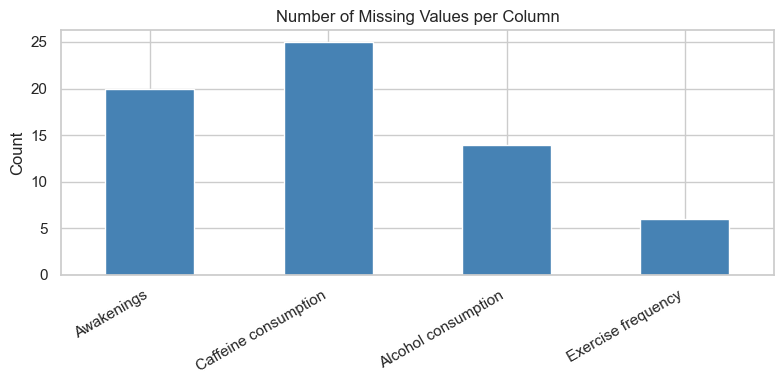

In [6]:
# Visualisera saknade värden
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(8, 4))
missing.plot(kind='bar', color='steelblue')
plt.title('Number of Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# Fyll i saknade värden med medianen för numeriska kolumner
# Vi använder median istället för medelvärde eftersom den är mindre känslig för extremvärden
cols_to_fill = ['Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency']

for col in cols_to_fill:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'{col}: filled with median = {median_val}')

print('\nMissing values after cleaning:')
print(df.isnull().sum())

Awakenings: filled with median = 1.0
Caffeine consumption: filled with median = 25.0
Alcohol consumption: filled with median = 0.0
Exercise frequency: filled with median = 2.0

Missing values after cleaning:
ID                        0
Age                       0
Gender                    0
Bedtime                   0
Wakeup time               0
Sleep duration            0
Sleep efficiency          0
REM sleep percentage      0
Deep sleep percentage     0
Light sleep percentage    0
Awakenings                0
Caffeine consumption      0
Alcohol consumption       0
Smoking status            0
Exercise frequency        0
dtype: int64


In [8]:
# Ta bort kolumner vi inte behöver för modellen
# ID är bara ett radnummer, Bedtime och Wakeup time fångas redan av Sleep duration
df = df.drop(columns=['ID', 'Bedtime', 'Wakeup time'])

print('Columns after dropping:', df.columns.tolist())

Columns after dropping: ['Age', 'Gender', 'Sleep duration', 'Sleep efficiency', 'REM sleep percentage', 'Deep sleep percentage', 'Light sleep percentage', 'Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Smoking status', 'Exercise frequency']


In [9]:
# Koda om kategoriska variabler till siffror
# Kön: Female = 0, Male = 1
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

# Rökstatus: No = 0, Yes = 1
df['Smoking status'] = df['Smoking status'].map({'No': 0, 'Yes': 1})

print('Encoding done!')
df.head()

Encoding done!


,Age,Gender,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,65,0,6.0,0.88,18,70,12,0.0,0.0,0.0,1,3.0
1,69,1,7.0,0.66,19,28,53,3.0,0.0,3.0,1,3.0
2,40,0,8.0,0.89,20,70,10,1.0,0.0,0.0,0,3.0
3,40,0,6.0,0.51,23,25,52,3.0,50.0,5.0,1,1.0
4,57,1,8.0,0.76,27,55,18,3.0,0.0,3.0,0,3.0


In [10]:
# Kontrollera om det finns dubbletter
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


---
## 4. Exploratory Data Analysis (EDA)

Now that the data is clean, we want to explore it visually to understand patterns and relationships.
This is important for understanding what drives sleep efficiency.

### 4.1 Distribution of Sleep Efficiency (our target variable)

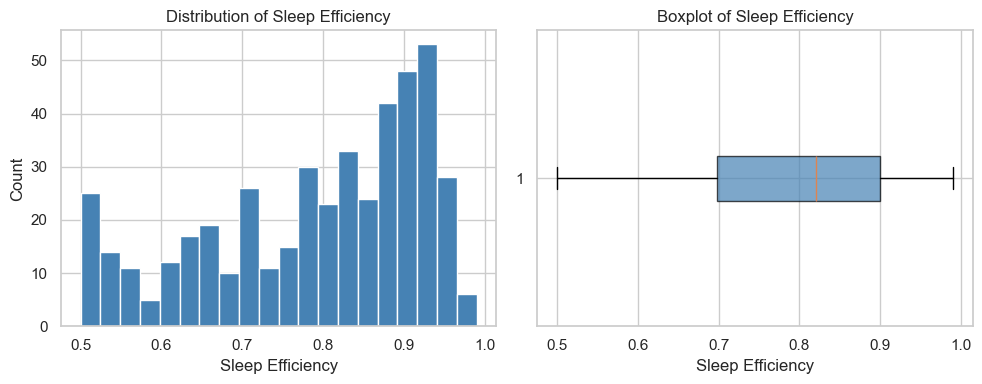

Mean sleep efficiency: 0.79
Median sleep efficiency: 0.82
Std deviation: 0.14


In [11]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['Sleep efficiency'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Sleep Efficiency')
plt.xlabel('Sleep Efficiency')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.boxplot(df['Sleep efficiency'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
plt.title('Boxplot of Sleep Efficiency')
plt.xlabel('Sleep Efficiency')

plt.tight_layout()
plt.show()

print(f"Mean sleep efficiency: {df['Sleep efficiency'].mean():.2f}")
print(f"Median sleep efficiency: {df['Sleep efficiency'].median():.2f}")
print(f"Std deviation: {df['Sleep efficiency'].std():.2f}")

### 4.2 Distribution of Key Variables

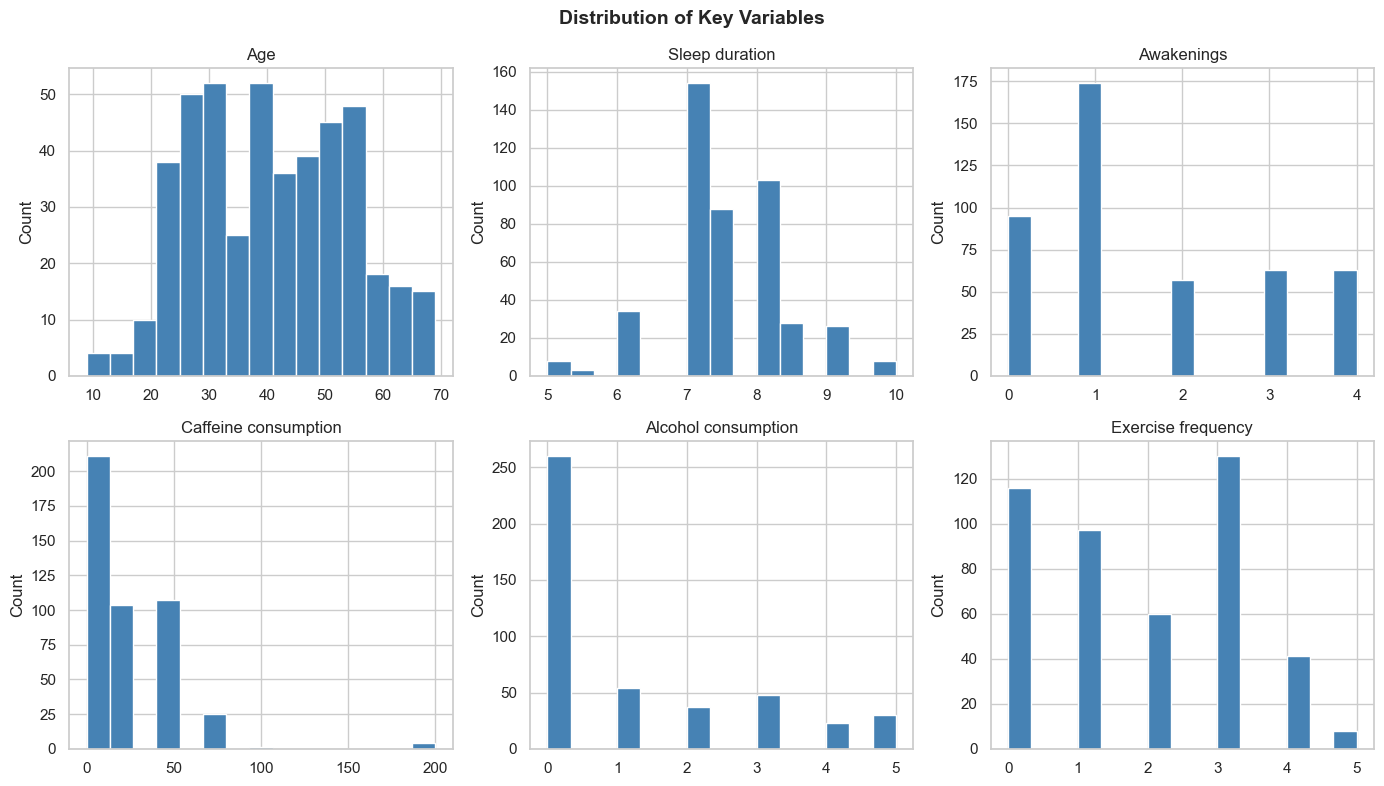

In [12]:
cols_to_plot = ['Age', 'Sleep duration', 'Awakenings', 'Caffeine consumption',
                'Alcohol consumption', 'Exercise frequency']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df[col], bins=15, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Sleep Efficiency vs Lifestyle Factors

/var/folders/7b/kbzrw4d15z3dj4gwlkzpj39w0000gn/T/ipykernel_14880/324185756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Caffeine consumption', y='Sleep efficiency', data=df, palette='Blues')


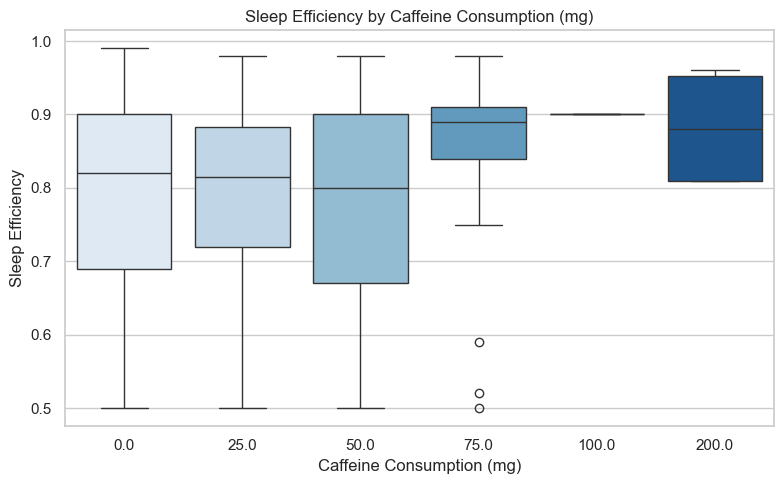

In [13]:
# Hur påverkar koffein sömneffektiviteten?
plt.figure(figsize=(8, 5))
sns.boxplot(x='Caffeine consumption', y='Sleep efficiency', data=df, palette='Blues')
plt.title('Sleep Efficiency by Caffeine Consumption (mg)')
plt.xlabel('Caffeine Consumption (mg)')
plt.ylabel('Sleep Efficiency')
plt.tight_layout()
plt.show()

/var/folders/7b/kbzrw4d15z3dj4gwlkzpj39w0000gn/T/ipykernel_14880/1577415859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Alcohol consumption', y='Sleep efficiency', data=df, palette='Oranges')


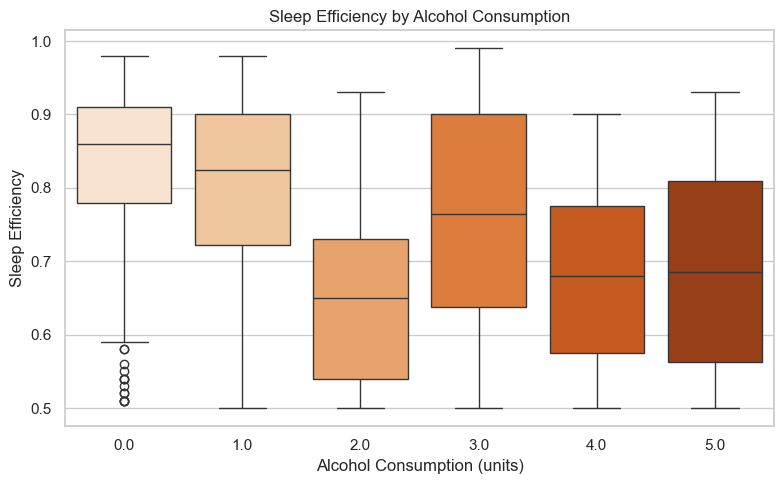

In [14]:
# Hur påverkar alkohol sömneffektiviteten?
plt.figure(figsize=(8, 5))
sns.boxplot(x='Alcohol consumption', y='Sleep efficiency', data=df, palette='Oranges')
plt.title('Sleep Efficiency by Alcohol Consumption')
plt.xlabel('Alcohol Consumption (units)')
plt.ylabel('Sleep Efficiency')
plt.tight_layout()
plt.show()

/var/folders/7b/kbzrw4d15z3dj4gwlkzpj39w0000gn/T/ipykernel_14880/3327119096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exercise frequency', y='Sleep efficiency', data=df, palette='Greens')


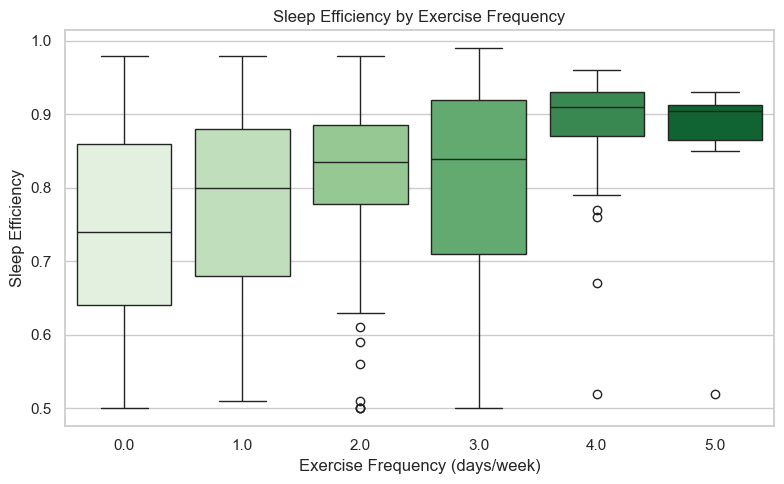

In [15]:
# Hur påverkar träningsfrekvens sömneffektiviteten?
plt.figure(figsize=(8, 5))
sns.boxplot(x='Exercise frequency', y='Sleep efficiency', data=df, palette='Greens')
plt.title('Sleep Efficiency by Exercise Frequency')
plt.xlabel('Exercise Frequency (days/week)')
plt.ylabel('Sleep Efficiency')
plt.tight_layout()
plt.show()

/var/folders/7b/kbzrw4d15z3dj4gwlkzpj39w0000gn/T/ipykernel_14880/255832696.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Smoking status', y='Sleep efficiency', data=df, palette='Set2')


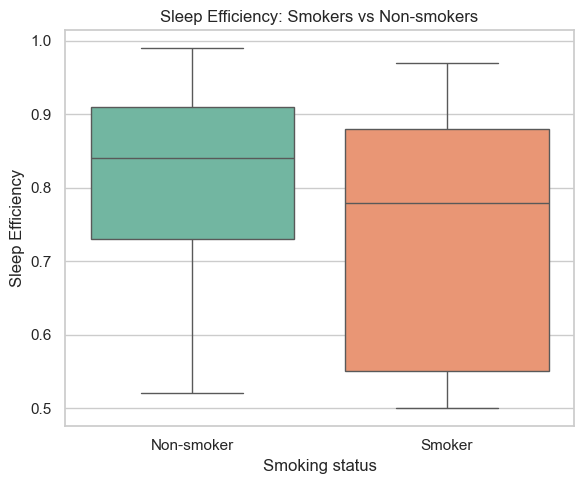

In [16]:
# Påverkar rökning sömneffektiviteten?
plt.figure(figsize=(6, 5))
sns.boxplot(x='Smoking status', y='Sleep efficiency', data=df, palette='Set2')
plt.xticks([0, 1], ['Non-smoker', 'Smoker'])
plt.title('Sleep Efficiency: Smokers vs Non-smokers')
plt.ylabel('Sleep Efficiency')
plt.tight_layout()
plt.show()

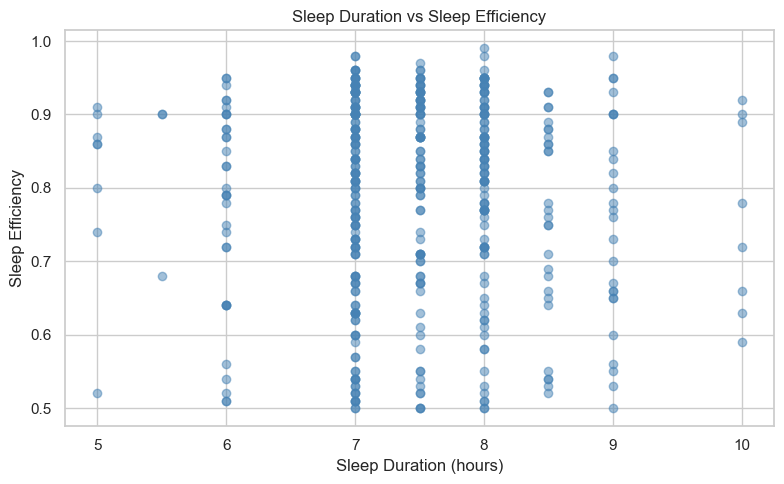

In [17]:
# Spridningsdiagram: Sömnduration vs sömneffektivitet
plt.figure(figsize=(8, 5))
plt.scatter(df['Sleep duration'], df['Sleep efficiency'], alpha=0.5, color='steelblue')
plt.title('Sleep Duration vs Sleep Efficiency')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Sleep Efficiency')
plt.tight_layout()
plt.show()

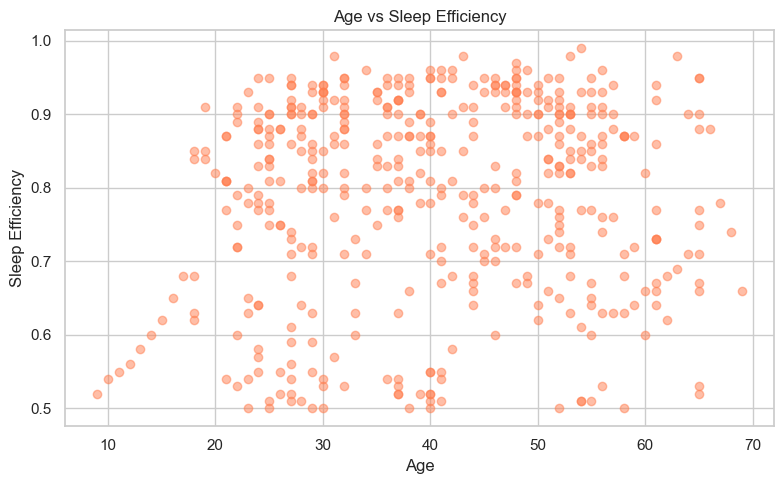

In [18]:
# Spridningsdiagram: Ålder vs sömneffektivitet
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Sleep efficiency'], alpha=0.5, color='coral')
plt.title('Age vs Sleep Efficiency')
plt.xlabel('Age')
plt.ylabel('Sleep Efficiency')
plt.tight_layout()
plt.show()

### 4.4 Correlation Matrix

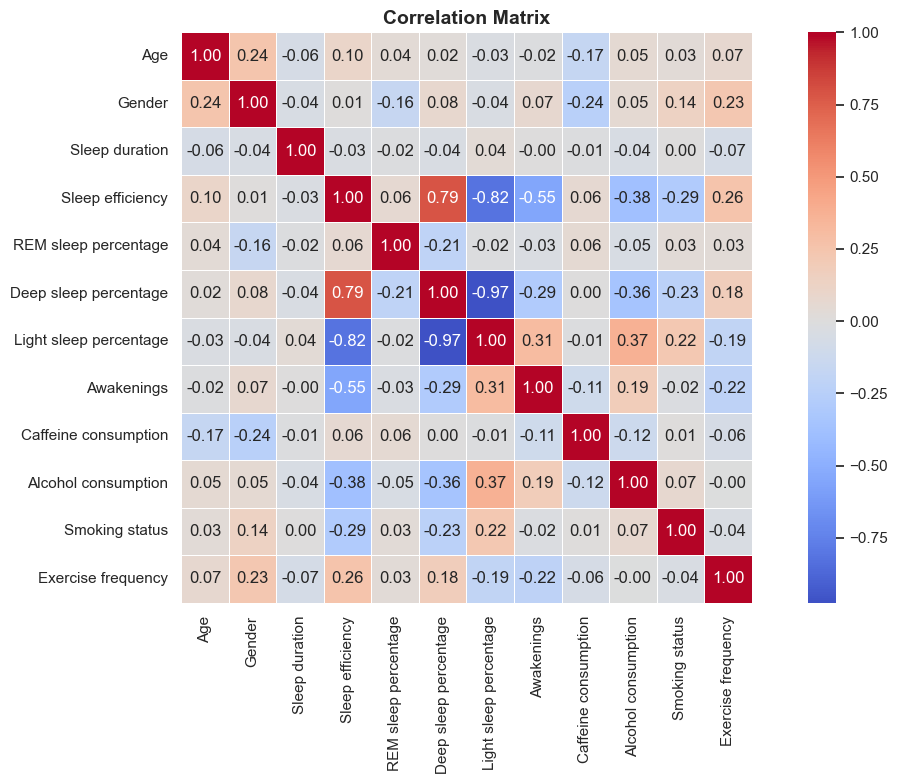

In [19]:
# Korrelationsmatrisen visar hur starkt variablerna är relaterade till varandra
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

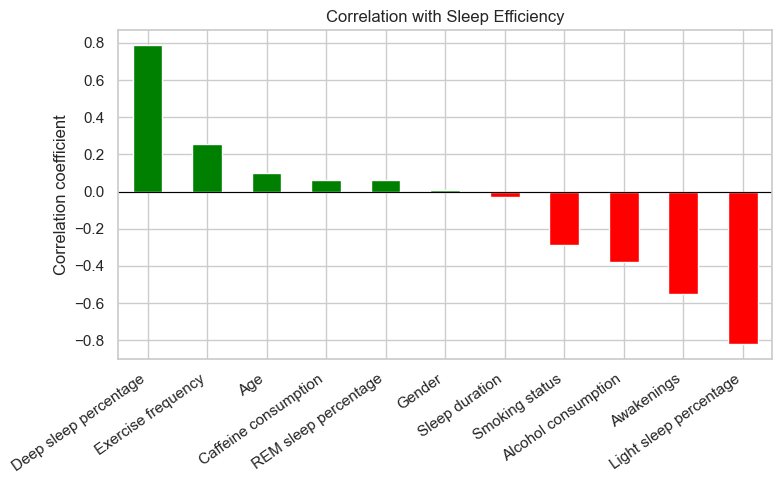

Deep sleep percentage     0.787335
Exercise frequency        0.257688
Age                       0.098357
Caffeine consumption      0.062904
REM sleep percentage      0.062362
Gender                    0.010062
Sleep duration           -0.027467
Smoking status           -0.290026
Alcohol consumption      -0.381249
Awakenings               -0.552179
Light sleep percentage   -0.819204
Name: Sleep efficiency, dtype: float64


In [20]:
# Vilka variabler korrelerar mest med sömneffektiviteten?
corr_with_target = corr['Sleep efficiency'].drop('Sleep efficiency').sort_values(ascending=False)

plt.figure(figsize=(8, 5))
corr_with_target.plot(kind='bar', color=['green' if x > 0 else 'red' for x in corr_with_target])
plt.title('Correlation with Sleep Efficiency')
plt.ylabel('Correlation coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print(corr_with_target)

---
## 5. Prepare Data for the Model

In [21]:
# Definiera features (X) och målvariabel (y)
# Vi tar bort sömnfaskolumnerna eftersom de är konsekvenser av sömneffektiviteten,
# inte orsaker – att ha kvar dem skulle låta modellen "fuska"
X = df.drop(columns=['Sleep efficiency', 'REM sleep percentage',
                      'Deep sleep percentage', 'Light sleep percentage'])
y = df['Sleep efficiency']

print('Features:', X.columns.tolist())
print('Target: Sleep efficiency')
print('Shape X:', X.shape)
print('Shape y:', y.shape)

Features: ['Age', 'Gender', 'Sleep duration', 'Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Smoking status', 'Exercise frequency']
Target: Sleep efficiency
Shape X: (452, 8)
Shape y: (452,)


In [22]:
# Dela upp i träningsset (80%) och testset (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])

Training samples: 361
Test samples: 91


In [23]:
# Skala om features med StandardScaler
# Detta ser till att alla variabler är på samma skala, vilket hjälper nätverket att träna bättre
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # träna skalaren på träningsdata
X_test_scaled = scaler.transform(X_test)         # använd samma skala på testdata

print('Scaling done!')

Scaling done!


---
## 6. Build the Neural Network Model

We build a simple Sequential model with two hidden layers.
Since this is a regression problem, the output layer has one neuron with no activation function.

In [24]:
# Sätt ett slumpmässigt frö för reproducerbarhet
tf.random.set_seed(42)

# Bygg modellen
model = keras.Sequential([
    # Ingångslager
    layers.Input(shape=(X_train_scaled.shape[1],)),

    # Första dolda lager
    layers.Dense(64, activation='relu'),

    # Andra dolda lager
    layers.Dense(32, activation='relu'),

    # Utgångslager – en neuron för regression (ingen aktiveringsfunktion)
    layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Kompilera modellen
# Adam-optimeraren justerar inlärningshastigheten automatiskt
# MSE (Mean Squared Error) är standardförlustfunktionen för regression
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']  # Mean Absolute Error – lättare att tolka
)

print('Model compiled!')

Model compiled!


---
## 7. Train the Model

In [26]:
# Träna modellen
# Vi använder 20% av träningsdatan som validering för att övervaka overfitting
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1276 - mae: 0.2992 - val_loss: 0.0457 - val_mae: 0.1547
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0502 - mae: 0.1796 - val_loss: 0.0278 - val_mae: 0.1273
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0297 - mae: 0.1417 - val_loss: 0.0254 - val_mae: 0.1219
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0225 - mae: 0.1218 - val_loss: 0.0239 - val_mae: 0.1203
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0183 - mae: 0.1090 - val_loss: 0.0219 - val_mae: 0.1176
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0152 - mae: 0.0989 - val_loss: 0.0203 - val_mae: 0.1140
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0130 - mae: 0.0909 - val_loss: 0.0194 - val_mae: 0.1120
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0114 - mae: 0.0850 - val_loss: 0.0183 - val_mae: 0.1097
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.010

---
## 8. Evaluate the Model

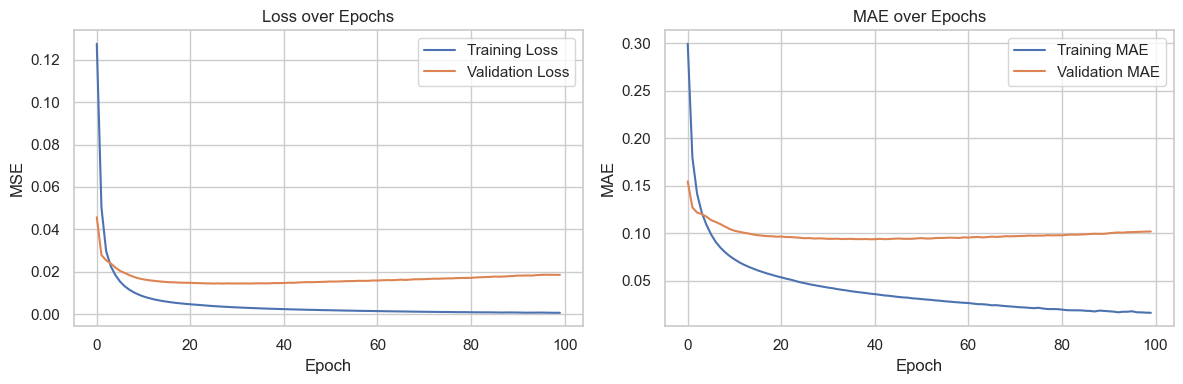

In [27]:
# Plotta träningshistorik – förlust över epoker
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# Utvärdera på testdata
y_pred = model.predict(X_test_scaled).flatten()

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('--- Model Performance on Test Data ---')
print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R²:   {r2:.4f}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
--- Model Performance on Test Data ---
MSE:  0.0133
RMSE: 0.1152
MAE:  0.0829
R²:   0.2870


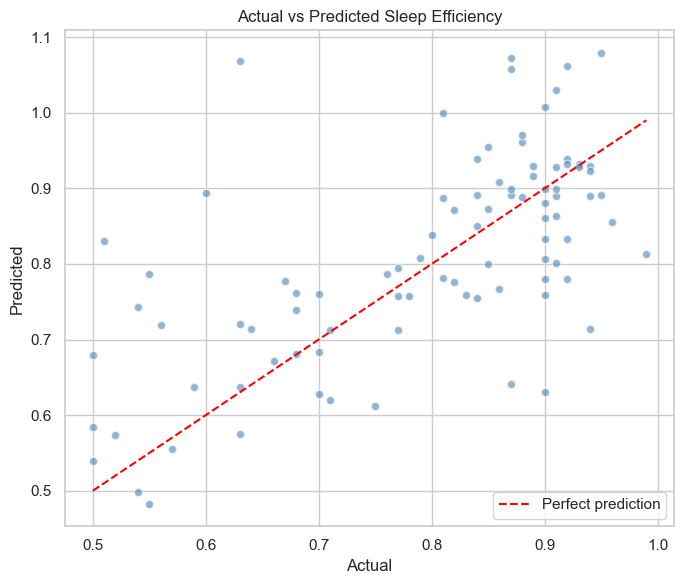

In [29]:
# Graf: Verklig vs förutsagd sömneffektivitet
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')
plt.title('Actual vs Predicted Sleep Efficiency')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.tight_layout()
plt.show()

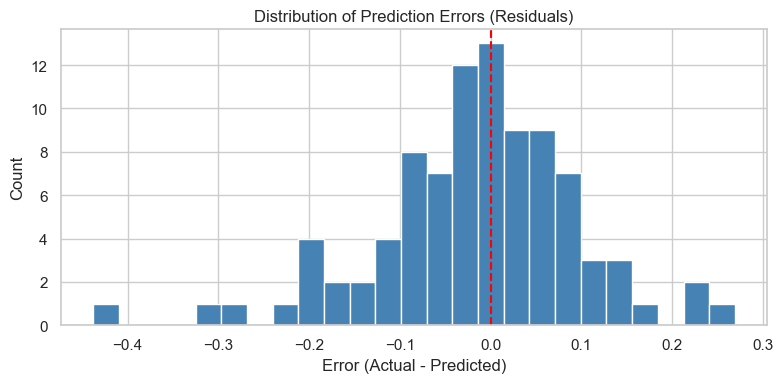

In [30]:
# Fördelning av prediktionsfel (residualer)
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=25, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

---
## 9. Save the Model and Scaler

We save the trained model and the scaler so they can be reused later without retraining.

In [31]:
# Skapa models/-mappen om den inte finns
os.makedirs('models', exist_ok=True)

# Spara modellen
model.save('models/sleep_efficiency_model.keras')
print('Model saved!')

# Spara skalaren
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved!')

Model saved!
Scaler saved!


---
## 10. Summary and Conclusions

In this project we built an Artificial Neural Network to predict sleep efficiency based on lifestyle factors.

**What we found in EDA:**
- *[Write your observations here after running the notebook – what patterns did you see?]*
- *[For example: Does caffeine clearly affect sleep efficiency? What about alcohol?]*

**Model performance:**
- *[Fill in your R², MAE and RMSE values here after training]*
- *[Comment on whether the model is good – is there overfitting?]*

**Can the model be improved?**
- Try adding more layers or neurons
- Try more epochs
- Try including the sleep phase columns (REM, deep, light)

**Business value:**
A health app or insurance company could use this model to give personalized sleep recommendations based on a user's lifestyle. By adjusting factors like caffeine intake or exercise frequency, the model can show how sleep efficiency would change – helping users make better decisions for their health.